In [83]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [2]:
from data_load import scaled_data, raw_data, result, data_info

In [3]:
scaled_data.head()

,Unnamed: 0,용접 가압력,전류,전압,통전시간
0,0,0.004482,0.001717,0.002506,0.000461
1,1,0.005412,0.000501,0.002506,0.000922
2,2,0.004989,0.000358,0.507830,0.000922
3,3,0.005243,0.000358,0.002506,0.000922
4,4,0.005327,0.000143,0.002506,0.000461


In [4]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [8]:
# Thickness는 모두 같은 값이므로 예측에 영향 X

print(np.sum(raw_data['Thickness 1(mm)'] != 0.7))
print(np.sum(raw_data['Thickness 2(mm)'] != 0.7))

0
0


In [12]:
scaled_data = scaled_data.drop(columns = ['Unnamed: 0'])

In [ ]:
# 이류

model = IsolationForest(contamination=0.0038, random_state=42)

model.fit(scaled_data)

predictions = model.predict(scaled_data)


In [45]:
idx = (predictions == -1)

X = scaled_data.loc[idx, :]

kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)

kmeans.fit(X)

labels = kmeans.labels_
print("각 데이터의 소속 그룹:", labels)

각 데이터의 소속 그룹: [1 0 0 0 0 0 0 1 1 1 0 2 2 0 0 0 0 0 0 0 0 1 1 1 0 0 2 2 0 1 0 0 0 0 0 2 1
 1 0 0 0 0 0 1 2 2]


In [73]:
X['cluster'] = labels

X.head()

,용접 가압력,전류,전압,통전시간,cluster
9,0.004989,0.000072,0.508875,0.000000,1
1882,0.061475,0.001645,0.000000,0.000461,0
1883,0.061475,0.002218,0.000000,0.000461,0
1884,0.061813,0.002218,0.000104,0.000461,0
1885,0.061813,0.002003,0.000104,0.000461,0


In [87]:
undercut_idx = result['defect'] == 1
crack_idx = result['defect'] == 3
lack_idx = result['defect'] == 2

anomaly1 = np.sum(labels == 0) # 파임불량
anomaly2 = np.sum(labels == 1) # 크랙발생
anomaly3 = np.sum(labels == 2) # 용접부족
print(anomaly1, anomaly2, anomaly3)
print()

defect = pd.Series(result['defect'], dtype=int)
print(np.sum(defect[undercut_idx]),np.sum(defect[crack_idx]), np.sum(defect[lack_idx]))

28 11 7

9 12 18


In [75]:
anomaly1 = X.loc[X['cluster'] == 0, :]
anomaly2 = X.loc[X['cluster'] == 1, :]
anomaly3 = X.loc[X['cluster'] == 2, :]

In [79]:
anomaly1.head(5)

,용접 가압력,전류,전압,통전시간,cluster
1882,0.061475,0.001645,0.000000,0.000461,0
1883,0.061475,0.002218,0.000000,0.000461,0
1884,0.061813,0.002218,0.000104,0.000461,0
1885,0.061813,0.002003,0.000104,0.000461,0
1886,0.061728,0.002003,0.000418,0.000461,0


In [78]:
anomaly2.head()

,용접 가압력,전류,전압,통전시간,cluster
9,0.004989,0.000072,0.508875,0.000000,1
1934,0.042280,0.003362,0.550637,0.000922,1
1943,0.043210,0.003076,0.686782,0.000922,1
1944,0.043210,0.003076,0.791188,0.000922,1
4748,0.042280,0.003362,0.550637,0.000922,1


In [80]:
anomaly3.head()

,용접 가압력,전류,전압,통전시간,cluster
2108,0.052173,0.003219,0.003132,0.945622,2
2109,0.052258,0.003219,0.003132,0.511521,2
4922,0.052173,0.003219,0.003132,0.945622,2
4923,0.052258,0.003219,0.003132,0.521659,2
8031,0.052258,0.003219,0.003132,0.484793,2


C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing 

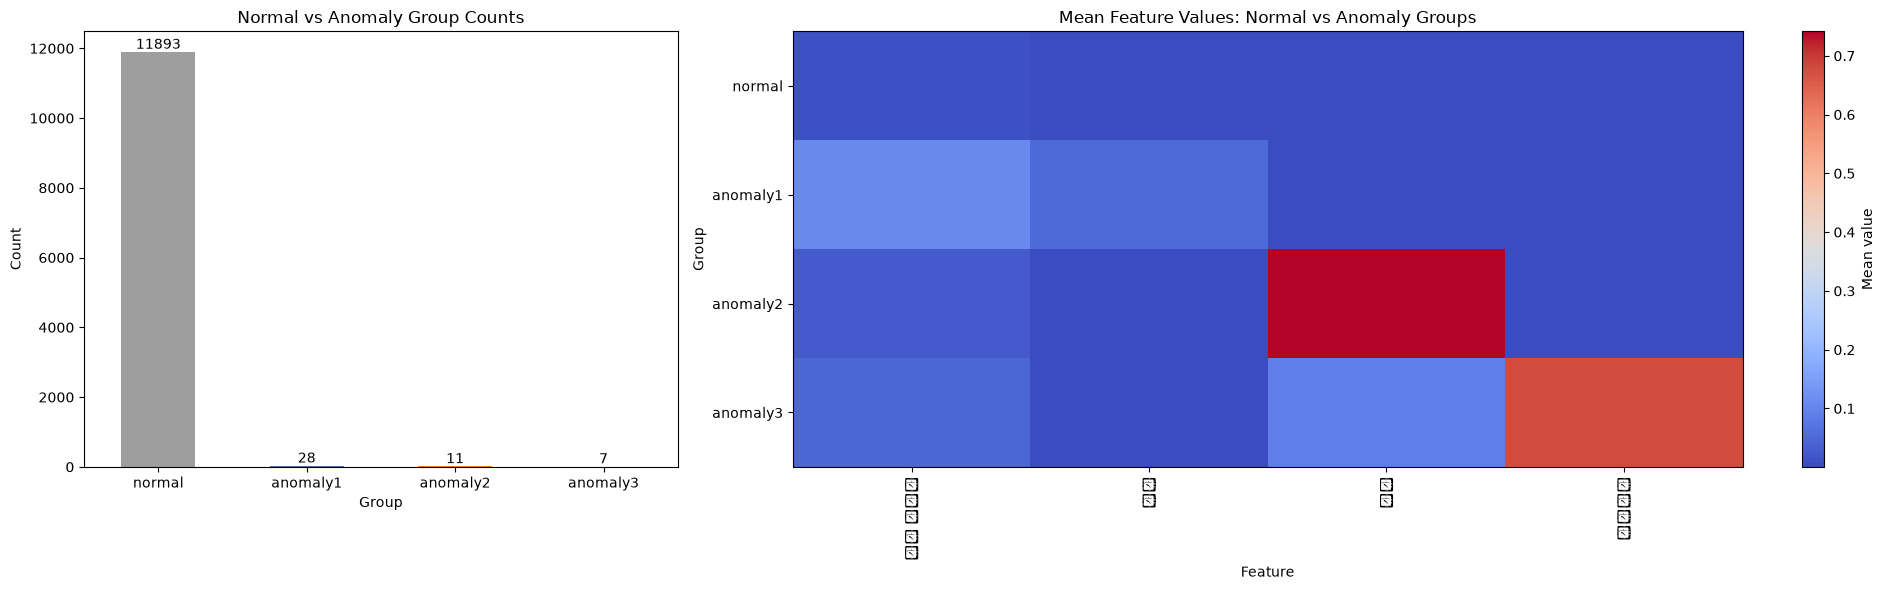

,normal,anomaly1,anomaly2,anomaly3
용접 가압력,0.011,0.110,0.029,0.045
전류,0.003,0.051,0.003,0.003
전압,0.003,0.001,0.742,0.090
통전시간,0.003,0.001,0.001,0.676


In [85]:
# Isolation Forest에서 정상으로 판정된 데이터
normal_data = scaled_data.loc[predictions == 1, :]

comparison_groups = {
    'normal': normal_data,
    'anomaly1': anomaly1,
    'anomaly2': anomaly2,
    'anomaly3': anomaly3,
}

# 정상 데이터와 anomaly 그룹별 데이터 개수 비교
counts = pd.Series({name: len(group) for name, group in comparison_groups.items()})

fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 2]})

counts.plot(kind='bar', ax=axes[0], color=['#9E9E9E', '#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Normal vs Anomaly Group Counts')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for index, value in enumerate(counts):
    axes[0].text(index, value, str(value), ha='center', va='bottom')

# 정상 데이터와 anomaly 그룹의 변수별 평균값 비교
mean_values = pd.DataFrame({name: group.drop(columns='cluster', errors='ignore').mean()
                            for name, group in comparison_groups.items()})
mean_values = mean_values.select_dtypes(include='number')

image = axes[1].imshow(mean_values.T, aspect='auto', cmap='coolwarm')
axes[1].set_title('Mean Feature Values: Normal vs Anomaly Groups')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Group')
axes[1].set_xticks(range(len(mean_values.index)))
axes[1].set_xticklabels(mean_values.index, rotation=90)
axes[1].set_yticks(range(len(mean_values.columns)))
axes[1].set_yticklabels(mean_values.columns)
fig.colorbar(image, ax=axes[1], label='Mean value')

plt.tight_layout()
plt.show()

mean_values.round(3)
